In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

d:\PROJECT\BookSage AI\book_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df = pd.read_pickle("dataset\\cleaned_book_dataset.pkl")

In [5]:
model = SentenceTransformer("models\\custom_embedding_model")

W0305 13:51:28.380000 35620 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [6]:
embeddings = model.encode(df["document"].tolist(), show_progress_bar=True)

Batches: 100%|██████████| 165/165 [00:10<00:00, 16.36it/s]


In [7]:
sim_matrix = cosine_similarity(embeddings)

In [8]:
k = 5
correct = 0
total = len(df)

In [9]:
for i in range(total):
    sim_scores = sim_matrix[i]
    top_k_idx = np.argsort(sim_scores)[-k-1:-1]

    same_genre_count = sum(
        df.iloc[i]["Main Genre"] == df.iloc[j]["Main Genre"]
        for j in top_k_idx
    )

    correct += same_genre_count / k

In [10]:
precision_at_k = correct / total

In [11]:
print(f"Precision@{k}: {precision_at_k:.4f}")

Precision@5: 1.0000


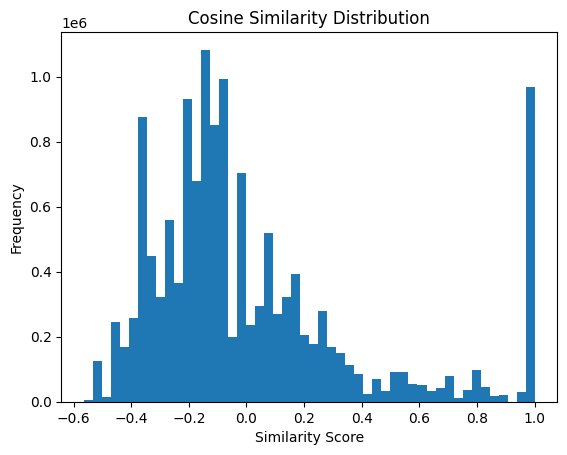

In [12]:
similarities = []

for i in range(total):
    for j in range(i+1, total):
        similarities.append(sim_matrix[i][j])

plt.hist(similarities, bins=50)
plt.title("Cosine Similarity Distribution")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.show()